In [1]:
pip install scikit-learn==1.6.1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix
import joblib
sns.set(style='whitegrid')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Weatherset/weather.csv')
print(df)

Mounted at /content/drive
            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


In [4]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [5]:
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [7]:
print("Missing Value:")
print(df.isnull().sum())

Missing Value:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['weather_encoded'] = le.fit_transform(df['weather'])

print(df[['weather', 'weather_encoded']].head())

   weather  weather_encoded
0  drizzle                0
1     rain                2
2     rain                2
3     rain                2
4     rain                2


In [ ]:
#Exploratory Data Analysis (EDA)

In [9]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       precipitation     temp_max     temp_min         wind  weather_encoded
count    1461.000000  1461.000000  1461.000000  1461.000000      1461.000000
mean        3.029432    16.439083     8.234771     3.241136         2.752225
std         6.680194     7.349758     5.023004     1.437825         1.191380
min         0.000000    -1.600000    -7.100000     0.400000         0.000000
25%         0.000000    10.600000     4.400000     2.200000         2.000000
50%         0.000000    15.600000     8.300000     3.000000         2.000000
75%         2.800000    22.200000    12.200000     4.000000         4.000000
max        55.900000    35.600000    18.300000     9.500000         4.000000


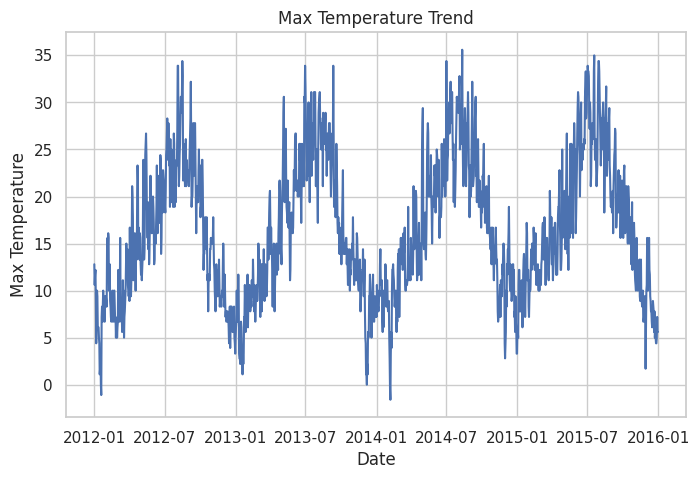

In [10]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

plt.figure(figsize=(8,5))
plt.plot(df["date"], df["temp_max"])
plt.title("Max Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Max Temperature")
plt.show()

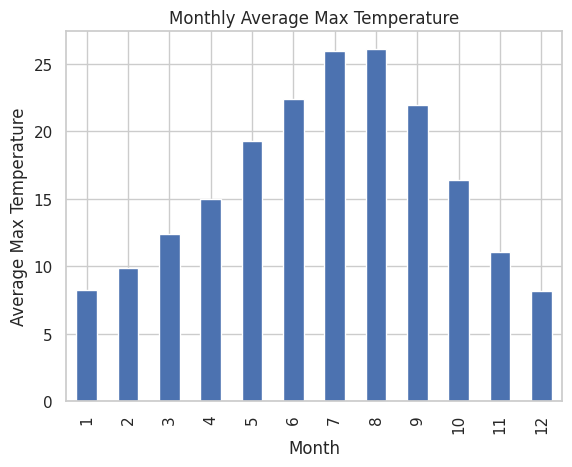

In [11]:
df["Month"] = df["date"].dt.month

monthly_avg = df.groupby("Month")["temp_max"].mean()

monthly_avg.plot(kind="bar")
plt.title("Monthly Average Max Temperature")
plt.xlabel("Month")
plt.ylabel("Average Max Temperature")
plt.show()

In [12]:
col_name = df.columns
col_name

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'weather_encoded', 'Month'],
      dtype='object')

In [13]:
df.nunique()

,0
date,1461
precipitation,111
temp_max,67
temp_min,55
wind,79
weather,5
weather_encoded,5
Month,12


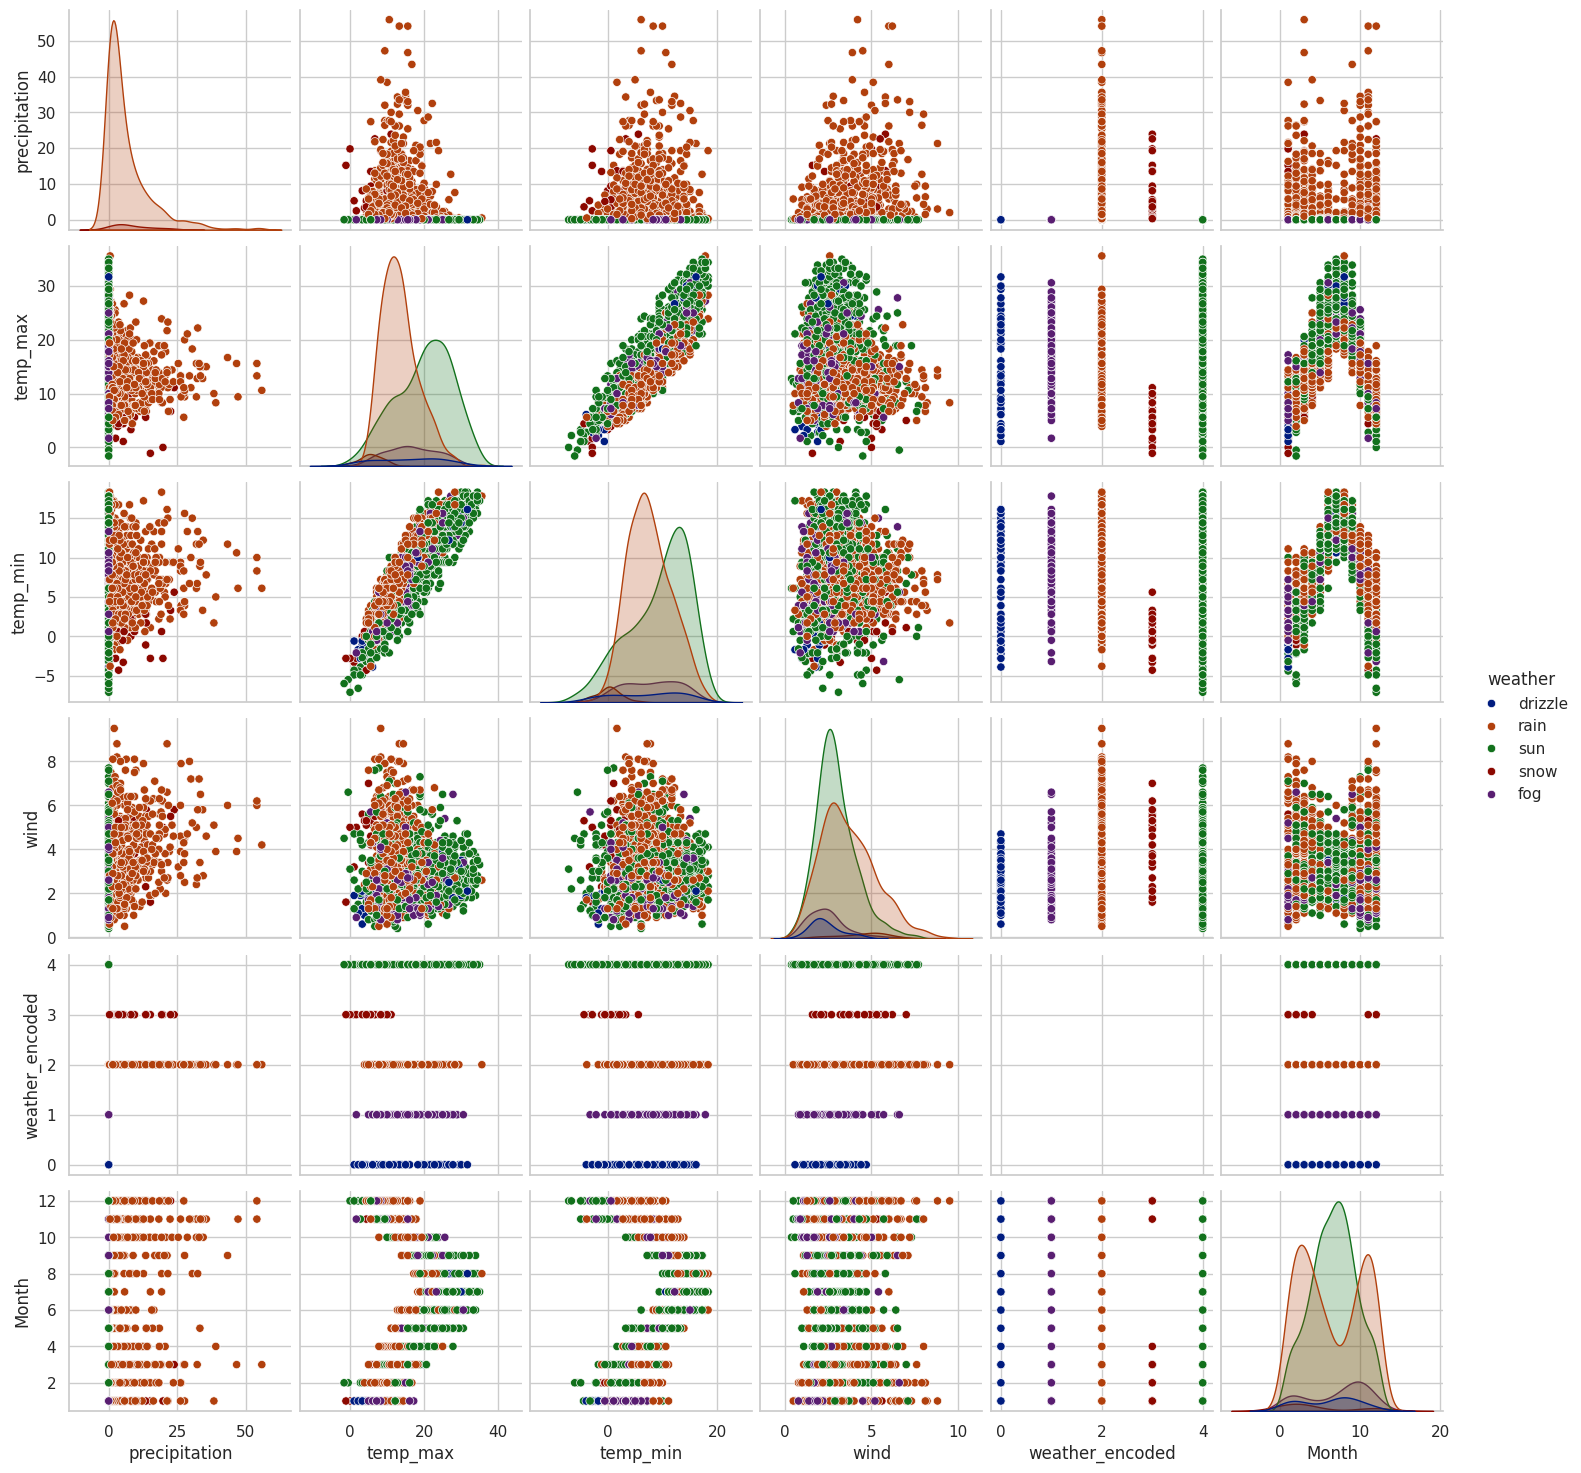

In [14]:
sns.pairplot(data=df, hue='weather', palette='dark')
plt.show()

In [15]:
import plotly.express as px

fig = px.histogram(df,
                   x='weather',
                   barmode='group',
                   color='weather',
                   text_auto=True)

fig.update_layout(title='Distribution of Weather Conditions',
                  title_font={'size':30},
                  showlegend=True)

fig.update_yaxes(showgrid=False)

fig.show()

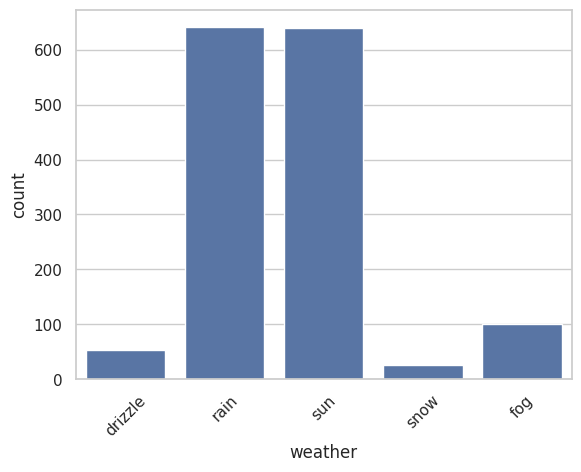

In [16]:
#Distribution df weather types
sns.countplot(x='weather', data=df)
plt.xticks(rotation=45)
plt.show()

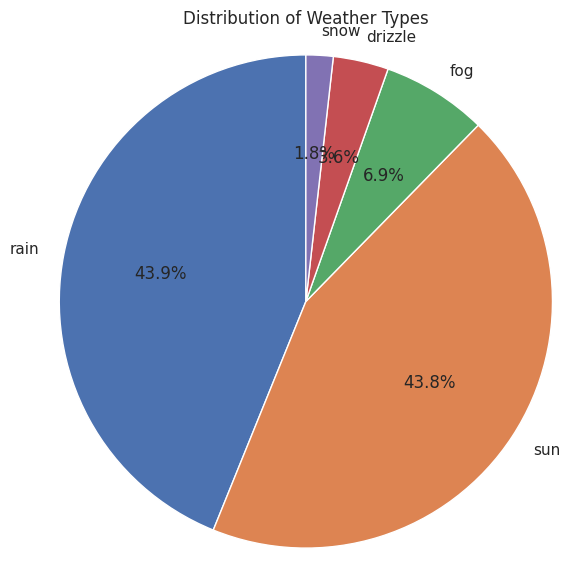

In [17]:
# Count each weather type
weather_counts = df['weather'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    weather_counts,
    labels=weather_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Weather Types")
plt.axis('equal')
plt.show()

/tmp/ipykernel_10677/1421336281.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/1421336281.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



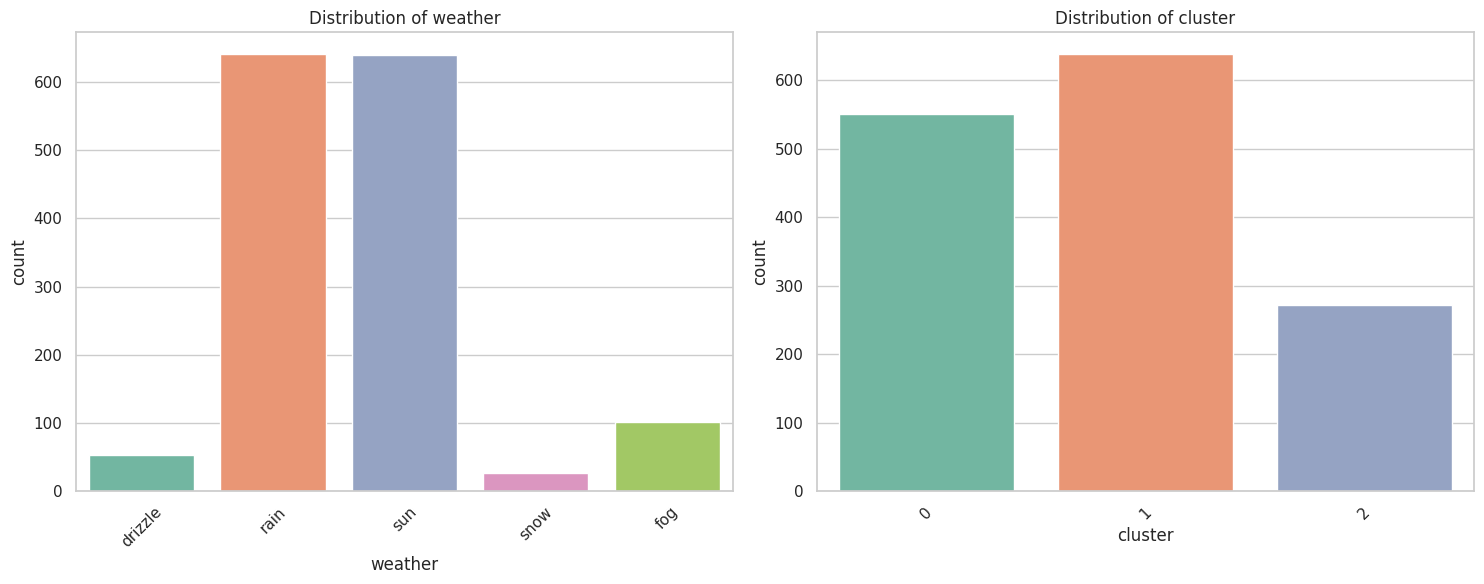

In [18]:
from sklearn.cluster import KMeans
if 'cluster' not in df.columns:

    features = ['precipitation', 'temp_max', 'temp_min', 'wind']
    X = df[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    df['cluster'] = clusters

cat_cols = ['weather', 'cluster']
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
axs = axs.flatten()

for i, var in enumerate(cat_cols):
    sns.countplot(x=var, data=df, ax=axs[i], hue=var, palette='Set2', legend=False)
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_title(f"Distribution of {var}")

fig.tight_layout()
plt.show()

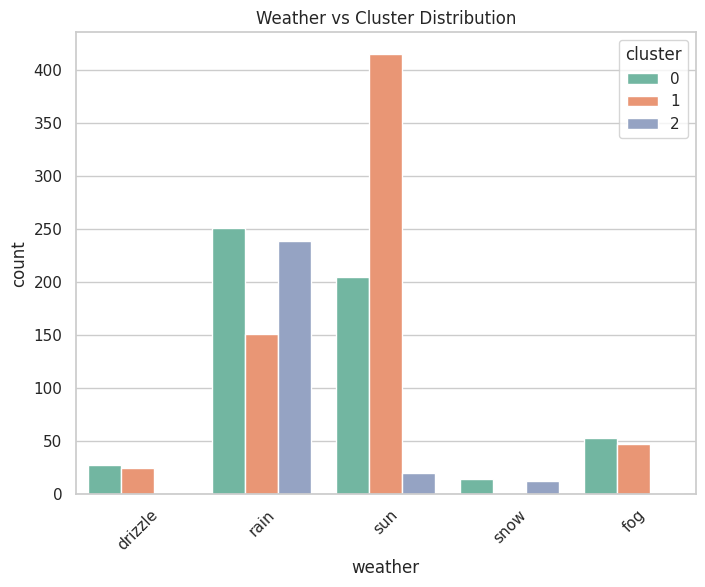

In [19]:
#Weather vs cluster
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

sns.countplot(
    x='weather',
    hue='cluster',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Weather vs Cluster Distribution")
plt.show()

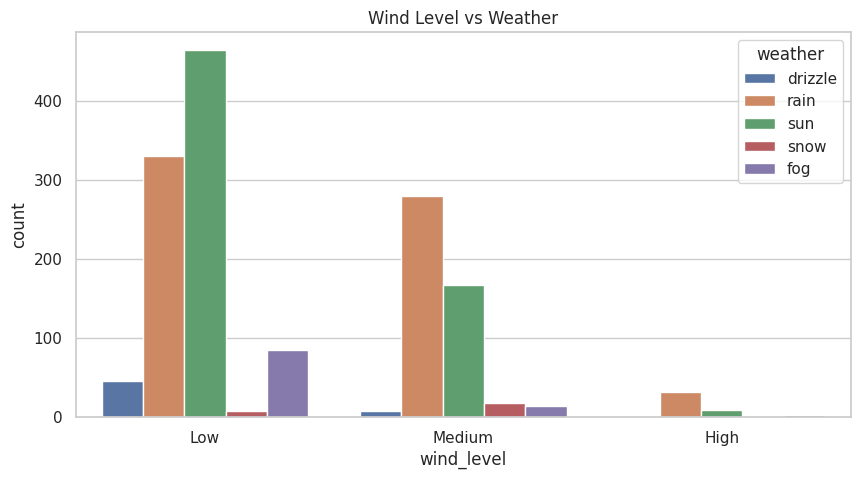

In [20]:
# Ensure 'wind_level' column exists
if 'wind_level' not in df.columns:
    df['wind_level'] = pd.cut(
        df['wind'],
        bins=3,
        labels=['Low','Medium','High']
    )

plt.figure(figsize=(10,5))

sns.countplot(
    x='wind_level',
    hue='weather',
    data=df
)

plt.title("Wind Level vs Weather")
plt.show()

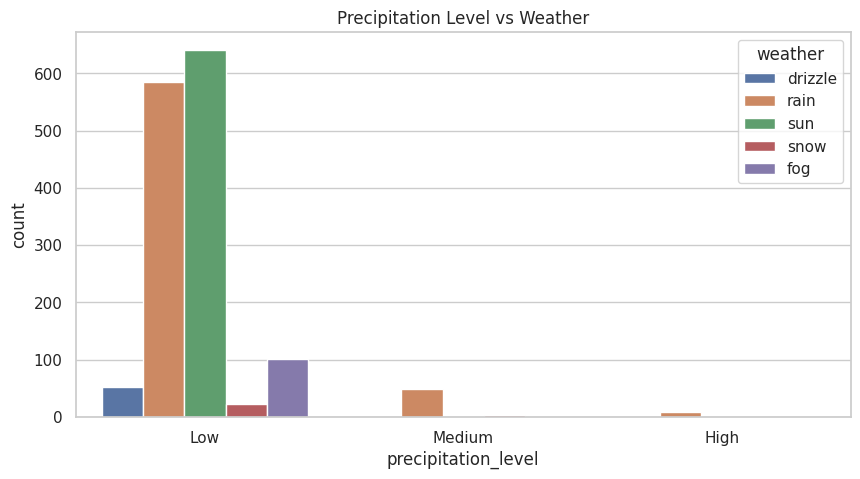

In [21]:
#Precipitation Level vs Weather
df['precipitation_level'] = pd.cut(
    df['precipitation'],
    bins=3,
    labels=['Low','Medium','High']
)

plt.figure(figsize=(10,5))

sns.countplot(
    x='precipitation_level',
    hue='weather',
    data=df
)

plt.title("Precipitation Level vs Weather")
plt.show()

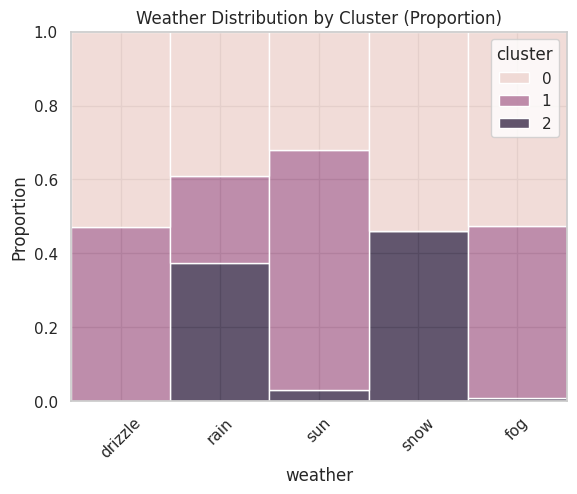

In [22]:
#Weather Type Distribution by Cluster (Percentage Fill)

sns.histplot(
    x='weather',
    hue='cluster',
    data=df,
    multiple='fill',
    kde=False,
    element='bars'
)

plt.xticks(rotation=45)
plt.title("Weather Distribution by Cluster (Proportion)")
plt.ylabel("Proportion")
plt.show()

/tmp/ipykernel_10677/1910696743.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/1910696743.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/1910696743.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



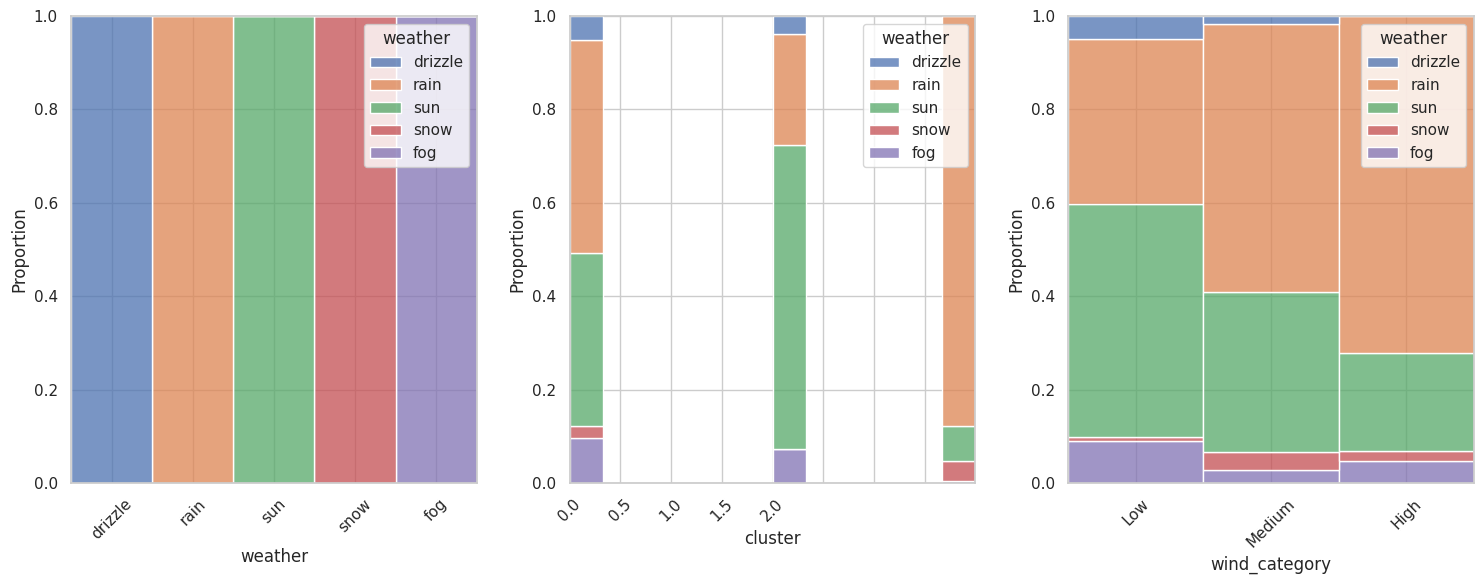

In [23]:
#Wind category and histogram loop
df['wind_category'] = pd.cut(
    df['wind'],
    bins=3,
    labels=['Low','Medium','High']
)
cat_cols = ['weather', 'cluster', 'wind_category']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
axs = axs.flatten()

for i, var in enumerate(cat_cols):
    sns.histplot(
        x=var,
        hue='weather',
        data=df,
        ax=axs[i],
        multiple='fill',
        kde=False,
        element='bars'
    )

    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel("Proportion")

fig.tight_layout()
plt.show()

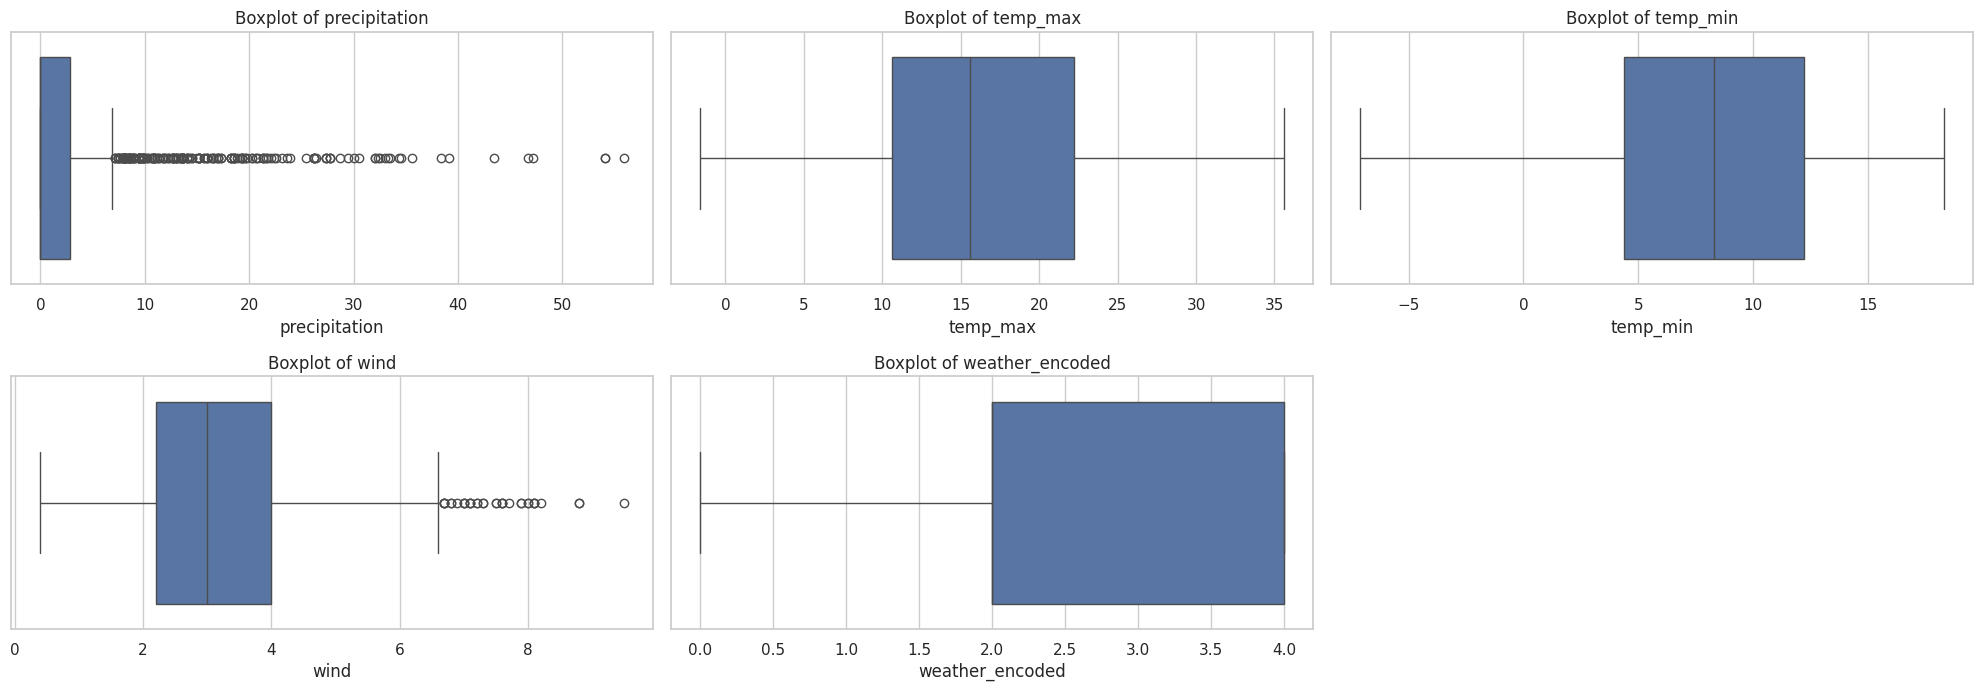

In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,10))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(x=var, data=df, ax=axs[i])
    axs[i].set_title(f"Boxplot of {var}")

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

/tmp/ipykernel_10677/3840108125.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/3840108125.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/3840108125.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_10677/3840108125.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



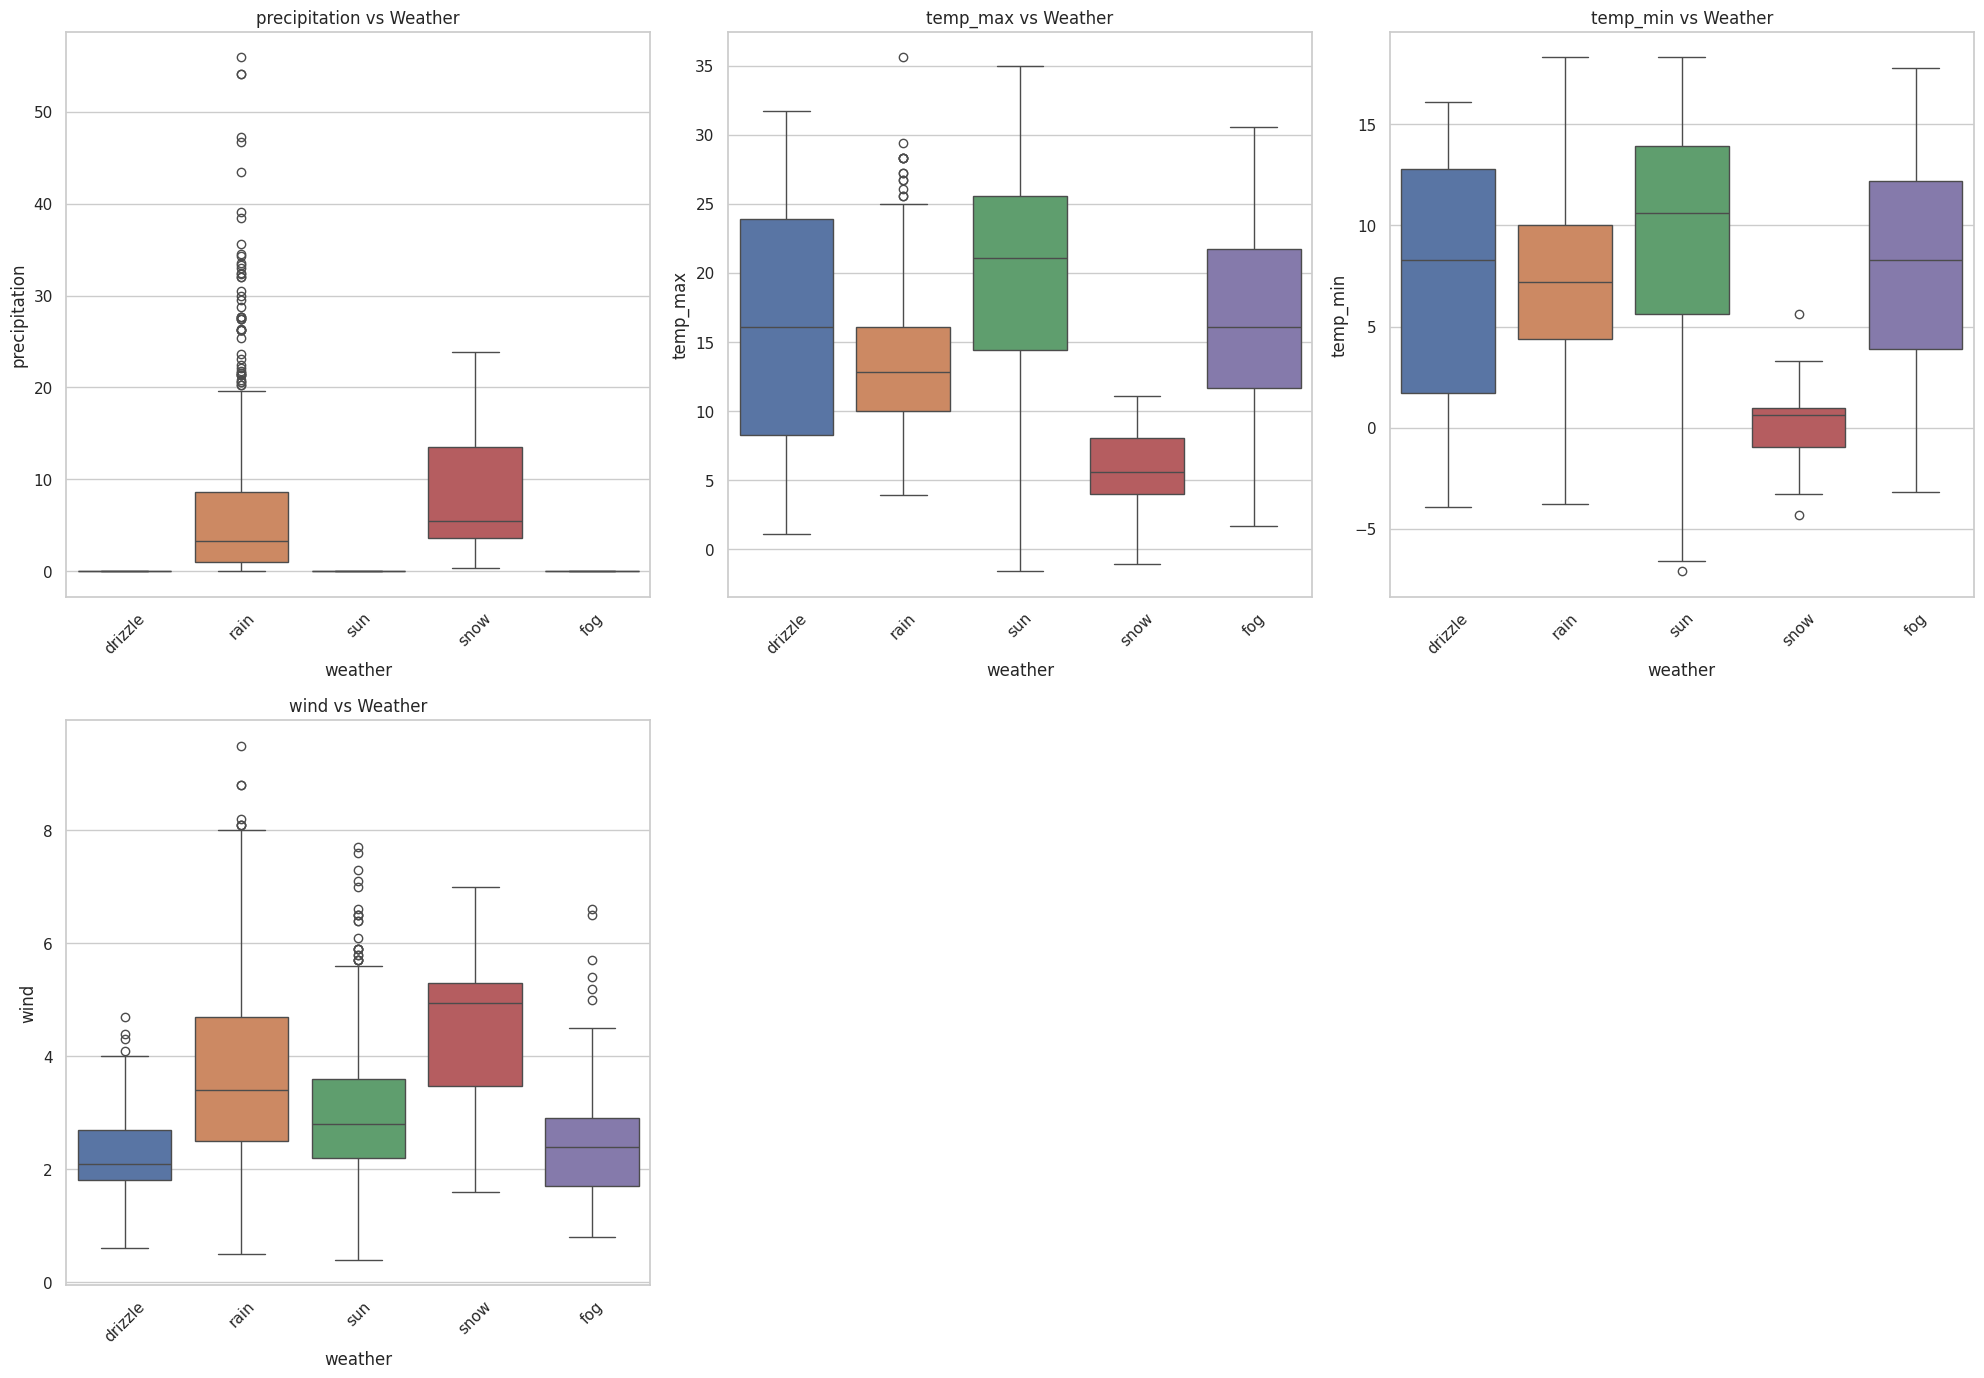

In [25]:
# Boxplot of Numerical features vs weather (without weather_encoded)

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('weather_encoded')

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,20))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(
        y=var,
        x='weather',
        hue='weather',
        data=df,
        ax=axs[i],
        legend=False
    )
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_title(f"{var} vs Weather")

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

/tmp/ipykernel_10677/2163398759.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



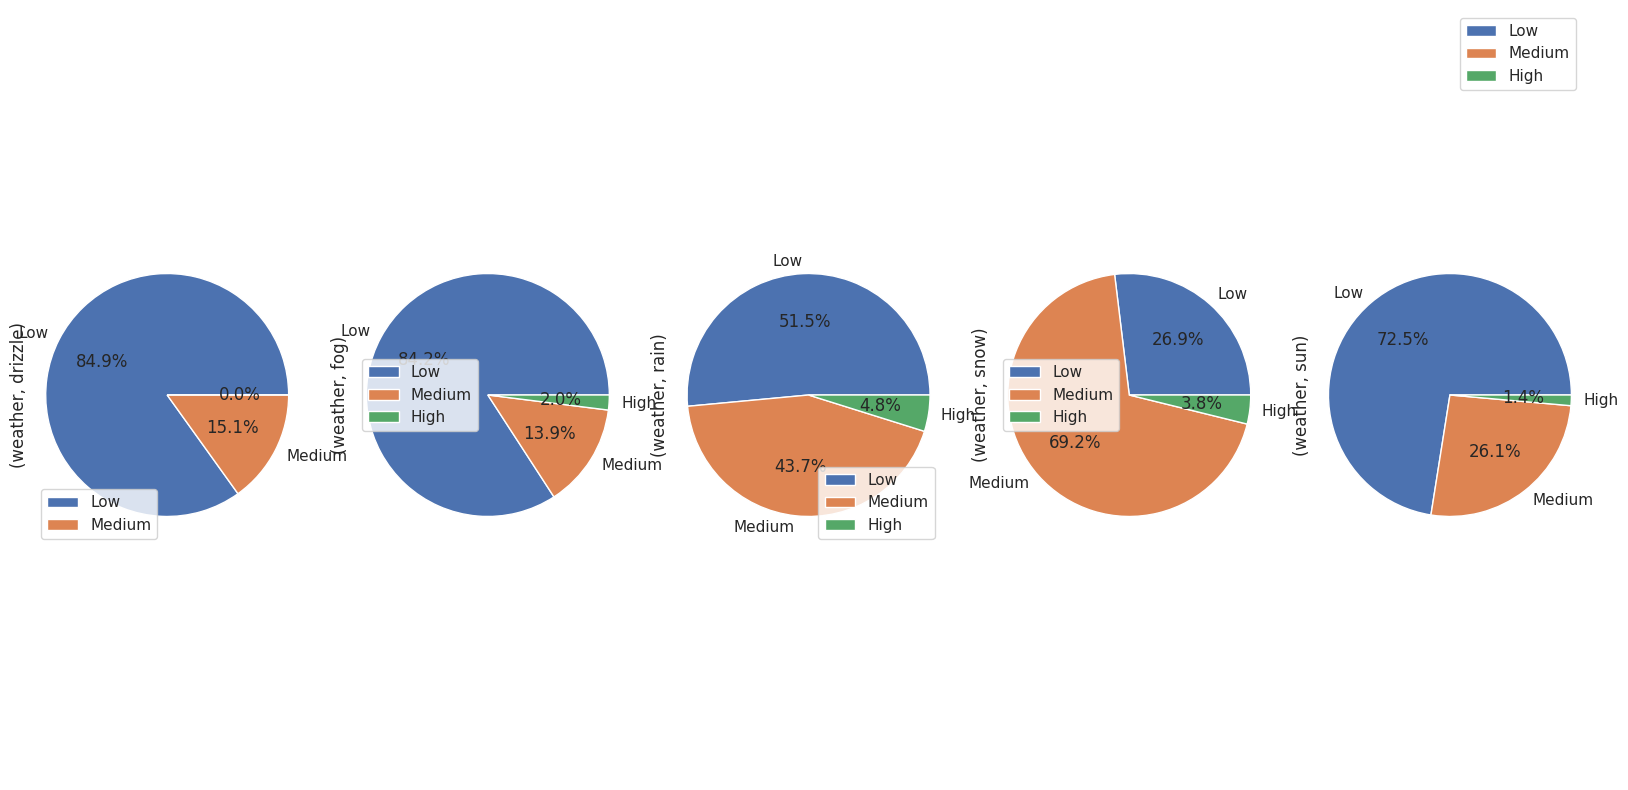

In [26]:
#pivot & pie
df.pivot_table(
    index='wind_level',
    columns='weather',
    aggfunc={'weather':'count'}
).plot.pie(
    autopct='%1.1f%%',
    subplots=True,
    figsize=(20,10)
)

plt.axis('equal')
plt.show()

In [27]:
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0
weather_encoded,0
Month,0
cluster,0
wind_level,0


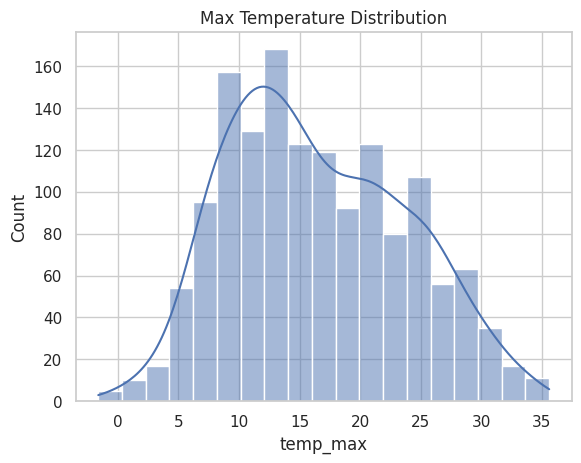

In [28]:
#Temperature distribution
sns.histplot(df['temp_max'], kde=True)
plt.title("Max Temperature Distribution")
plt.show()

In [29]:
df.corr(numeric_only=True)

,precipitation,temp_max,temp_min,wind,weather_encoded,Month,cluster
precipitation,1.000000,-0.228555,-0.072684,0.328045,-0.267388,0.027789,0.481799
temp_max,-0.228555,1.000000,0.875687,-0.164857,0.322337,0.154198,0.263098
temp_min,-0.072684,0.875687,1.000000,-0.074185,0.154981,0.216689,0.395824
wind,0.328045,-0.164857,-0.074185,1.000000,-0.065858,-0.048125,0.533305
weather_encoded,-0.267388,0.322337,0.154981,-0.065858,1.000000,0.022880,-0.042859
Month,0.027789,0.154198,0.216689,-0.048125,0.022880,1.000000,0.096221
cluster,0.481799,0.263098,0.395824,0.533305,-0.042859,0.096221,1.000000


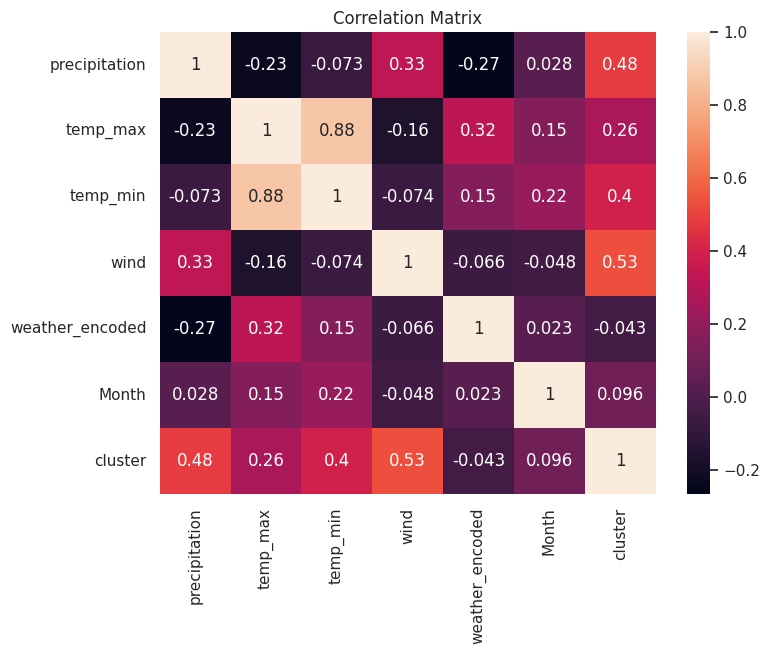

In [30]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

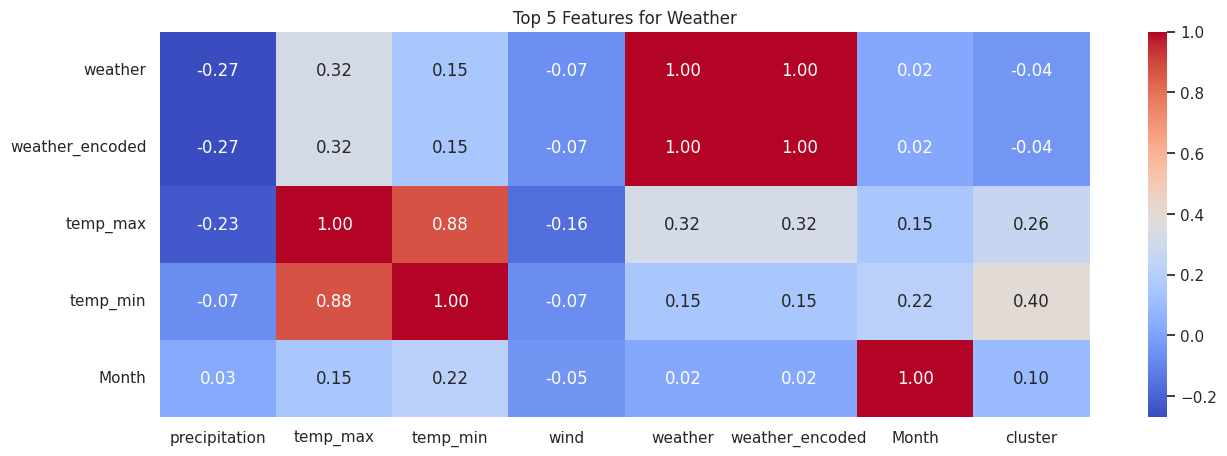

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])

corr = df.corr(numeric_only=True)
max_5_corr = corr.nlargest(5, 'weather')

plt.figure(figsize=(15,5))
sns.heatmap(max_5_corr, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Top 5 Features for Weather')
plt.show()

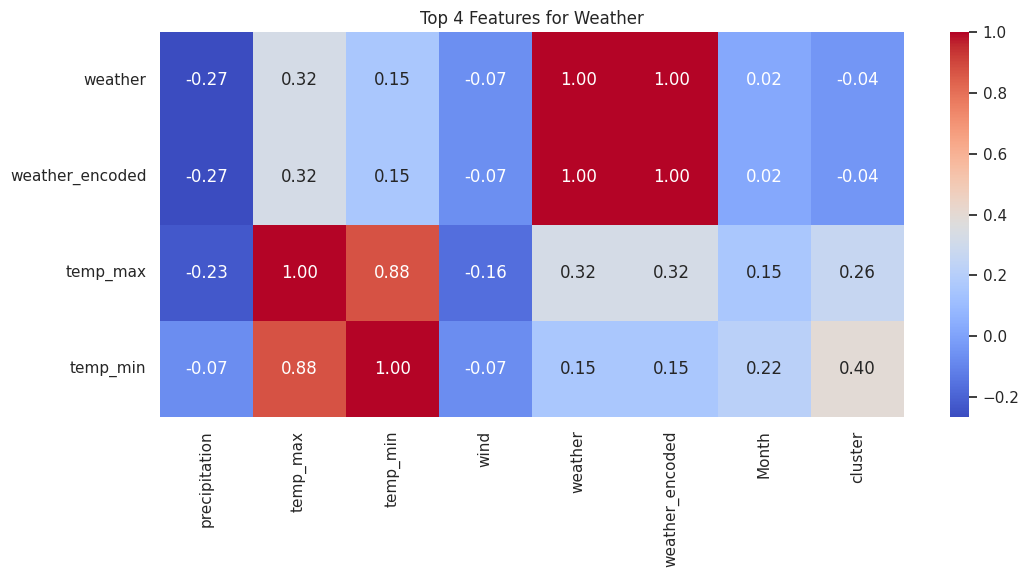

In [32]:
# Encode categorical weather
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])

corr = df.corr(numeric_only=True)
top_4_corr = corr.nlargest(4, 'weather')

plt.figure(figsize=(12,5))
sns.heatmap(top_4_corr, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Top 4 Features for Weather')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

# Features (input)
X = df[['precipitation', 'temp_max', 'temp_min', 'wind']]

# Target (output)
y = df['weather_encoded']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # same result every run
)

# Check shape
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 4)
X_test: (293, 4)
y_train: (1168,)
y_test: (293,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7781569965870307


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7303754266211604


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8156996587030717


In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7303754266211604


In [39]:
print("\nModel Comparison:")
print("Logistic:", accuracy_score(y_test, y_pred_log))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))


Model Comparison:
Logistic: 0.7781569965870307
Decision Tree: 0.7303754266211604
Random Forest: 0.8156996587030717
KNN: 0.7303754266211604


In [51]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
    "Accuracy (%)": [
        accuracy_score(y_test, y_pred_log) * 100,
        accuracy_score(y_test, y_pred_dt) * 100,
        accuracy_score(y_test, y_pred_rf) * 100,
        accuracy_score(y_test, y_pred_knn) * 100
    ]
})

print("\nModel Comparison Table:")
print(comparison_df)


Model Comparison Table:
                 Model  Accuracy (%)
0  Logistic Regression     77.815700
1        Decision Tree     73.037543
2        Random Forest     81.569966
3                  KNN     73.037543


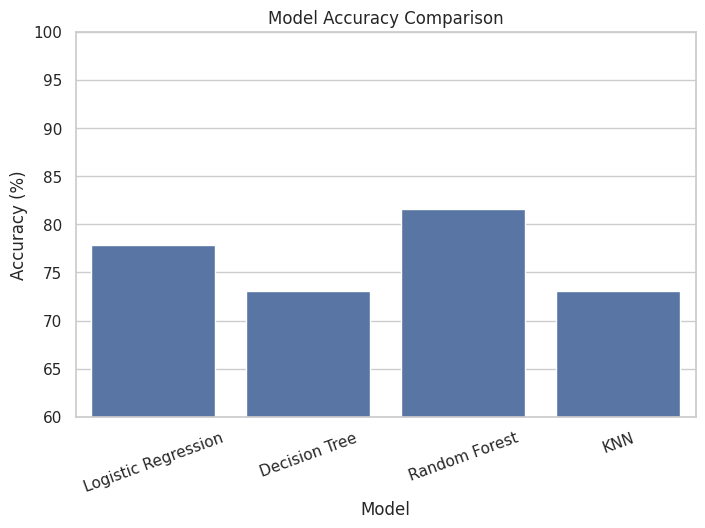

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(60, 100)
plt.show()

In [53]:
print("\nPerformance Analysis:")
print("Random Forest performed best with highest accuracy (~81%).")
print("Logistic Regression performed moderately well (~77%).")
print("Decision Tree showed slight overfitting.")
print("KNN performance depends on scaling and is average.")


Performance Analysis:
Random Forest performed best with highest accuracy (~81%).
Logistic Regression performed moderately well (~77%).
Decision Tree showed slight overfitting.
KNN performance depends on scaling and is average.


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

for name, pred in models.items():
    print(f"\n{name}:")
    print("Precision:", precision_score(y_test, pred, average='weighted'))
    print("Recall:", recall_score(y_test, pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, pred, average='weighted'))


Logistic Regression:
Precision: 0.7037092600232532
Recall: 0.7781569965870307
F1 Score: 0.7238739276762245

Decision Tree:
Precision: 0.7434594006147304
Recall: 0.7303754266211604
F1 Score: 0.7364706985736628

Random Forest:
Precision: 0.7784569684657945
Recall: 0.8156996587030717
F1 Score: 0.7835099772474666

KNN:
Precision: 0.714980239313107
Recall: 0.7303754266211604
F1 Score: 0.7089523948014029


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [55]:
print("\nFeature Importance Insight:")
print("Precipitation is the most important feature.")
print("Temperature (temp_max, temp_min) also strongly affects weather prediction.")
print("Wind has moderate influence.")


Feature Importance Insight:
Precipitation is the most important feature.
Temperature (temp_max, temp_min) also strongly affects weather prediction.
Wind has moderate influence.


         Feature  Importance
0  precipitation    0.523039
1       temp_max    0.187664
2       temp_min    0.147220
3           wind    0.142076


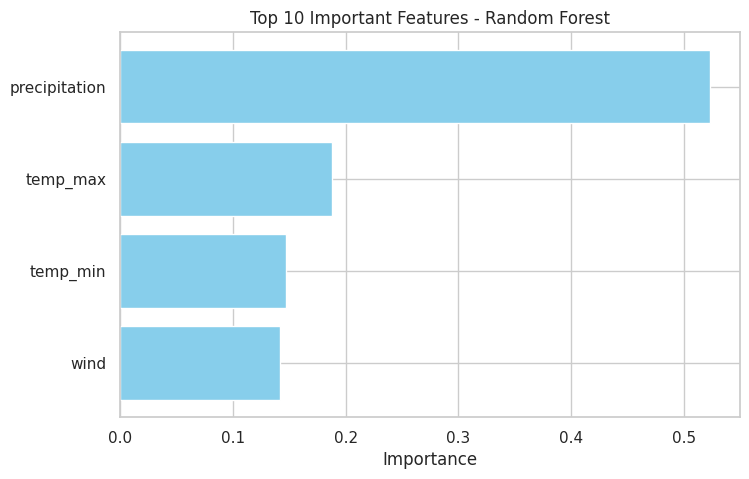

In [40]:
# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Top 10 features
top_features = feature_importances.head(10)
print(top_features)

# Plot Top 10 Features
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.show()

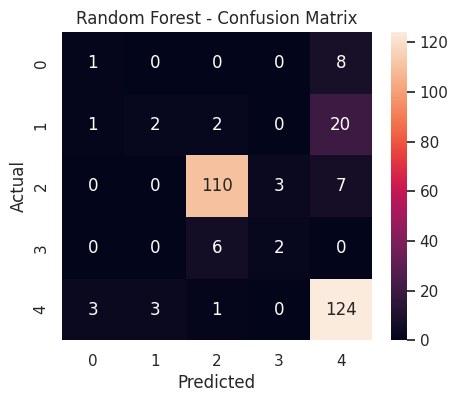

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)  # Example for Random Forest
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

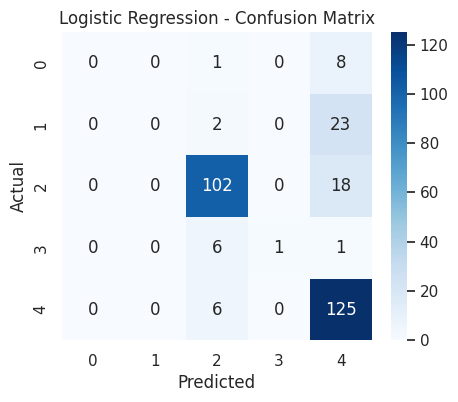

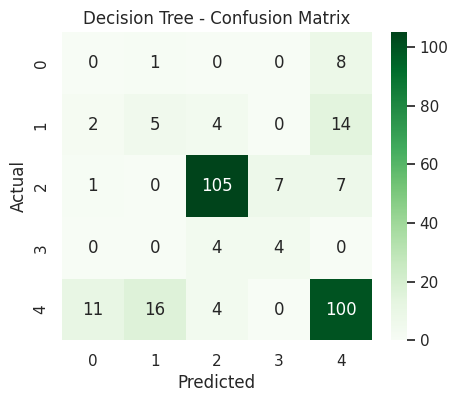

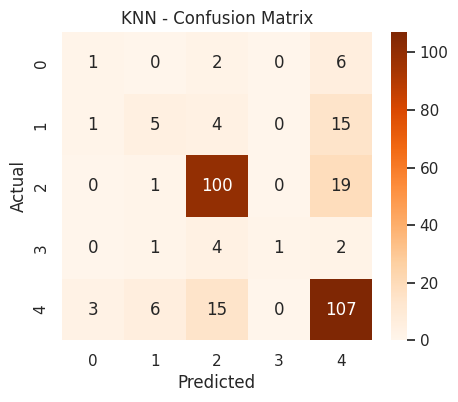

In [42]:
# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00        25
           2       0.87      0.85      0.86       120
           3       1.00      0.12      0.22         8
           4       0.71      0.95      0.82       131

    accuracy                           0.78       293
   macro avg       0.52      0.39      0.38       293
weighted avg       0.70      0.78      0.72       293

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.23      0.20      0.21        25
           2       0.90      0.88      0.89       120
           3       0.36      0.50      0.42         8
           4       0.78      0.76      0.77       131

    accuracy                           0.73       293
   macro avg       0.45      0.47      0.46       293
weighted avg       0.74  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [44]:
from sklearn.metrics import accuracy_score

accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

for model, acc in accuracy_results.items():
    print(f"{model} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7782
Decision Tree Accuracy: 0.7304
Random Forest Accuracy: 0.8157
KNN Accuracy: 0.7304


In [45]:
from sklearn.metrics import accuracy_score

accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log) * 100,
    "Decision Tree": accuracy_score(y_test, y_pred_dt) * 100,
    "Random Forest": accuracy_score(y_test, y_pred_rf) * 100,
    "KNN": accuracy_score(y_test, y_pred_knn) * 100
}

for model, acc in accuracy_results.items():
    print(f"{model} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 77.82%
Decision Tree Accuracy: 73.04%
Random Forest Accuracy: 81.57%
KNN Accuracy: 73.04%


/tmp/ipykernel_10677/340205015.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




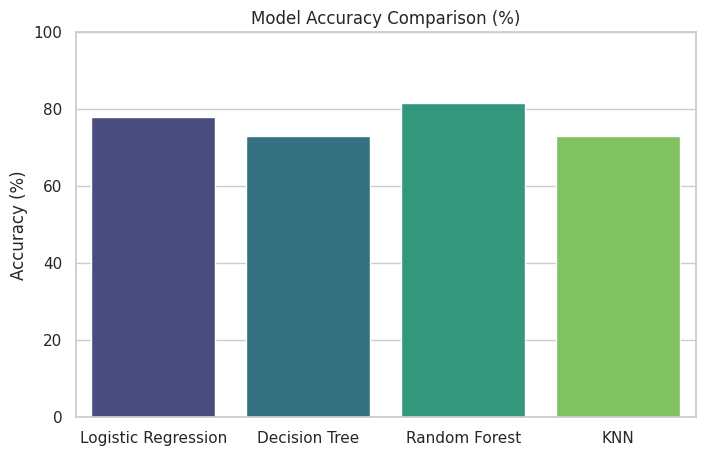

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette="viridis")
plt.title("Model Accuracy Comparison (%)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()

In [47]:
import joblib
joblib.dump(rf_model, "weather_rf_model.pkl")
print("Model saved as 'weather_rf_model.pkl'")

Model saved as 'weather_rf_model.pkl'


In [48]:
import joblib

joblib.dump(rf_model, "weather_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [49]:
weather_model = joblib.load("weather_classifier.pkl")
scaler = joblib.load("scaler.pkl")
le = joblib.load("label_encoder.pkl")

In [50]:
from google.colab import files
files.download("weather_classifier.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>